In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.compose import ColumnTransformer

In [50]:
df = sns.load_dataset('titanic')

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [51]:
df['family'] = df['sibsp'] + df['parch']

In [36]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [52]:
df = df[['age','fare','family','embarked','survived']]

In [38]:
df.head()

,age,fare,family,survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       714 non-null    float64
 1   fare      891 non-null    float64
 2   family    891 non-null    int64  
 3   embarked  889 non-null    object 
 4   survived  891 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


In [11]:
age_mean = df['age'].mean()

In [14]:
age_median = df['age'].median()

In [18]:
df['mean_age'] = df['age'].fillna(age_mean)
df['median_age'] = df['age'].fillna(age_median)

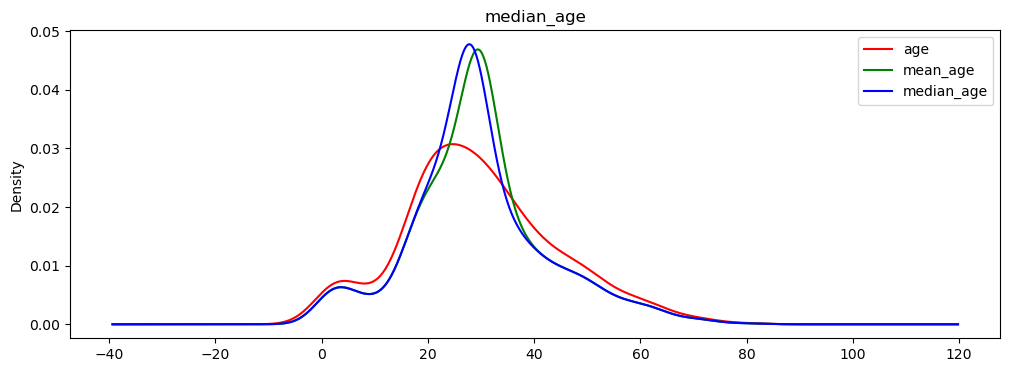

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,1,1)
df['age'].plot.density(color='red')
plt.title('age')

df['mean_age'].plot.density(color='green')
plt.title('mean_age')

df['median_age'].plot.density(color='blue')
plt.title('median_age')

plt.legend()
plt.show()

<Axes: >

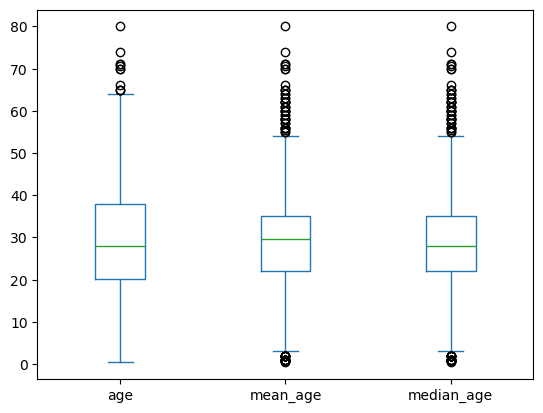

In [26]:
df[['age','mean_age','median_age']].plot(kind='box')

In [19]:
df.sample(5)

,age,fare,family,survived,mean_age,median_age
140,NaN,15.2458,2,0,29.699118,28.0
401,26.0,8.0500,0,0,26.000000,26.0
505,18.0,108.9000,1,0,18.000000,18.0
211,35.0,21.0000,0,1,35.000000,35.0
708,22.0,151.5500,0,1,22.000000,22.0


In [20]:
impute_mean = SimpleImputer()
impute_median = SimpleImputer(strategy='median')

In [31]:
df['age'][df['age'].isnull()] = df['age'].dropna().sample(df['age'].isnull().sum()).values

In [32]:
df

,age,fare,family,survived,mean_age,median_age
0,22.0,7.2500,1,0,22.000000,22.0
1,38.0,71.2833,1,1,38.000000,38.0
2,26.0,7.9250,0,1,26.000000,26.0
3,35.0,53.1000,1,1,35.000000,35.0
4,35.0,8.0500,0,0,35.000000,35.0
...,...,...,...,...,...,...
886,27.0,13.0000,0,0,27.000000,27.0
887,19.0,30.0000,0,1,19.000000,19.0
888,22.0,23.4500,3,0,29.699118,28.0
889,26.0,30.0000,0,1,26.000000,26.0


In [45]:
si = SimpleImputer(add_indicator=True)

In [47]:
df = si.fit_transform(df[['age']])

In [48]:
df

array([[22.        ,  0.        ],
       [38.        ,  0.        ],
       [26.        ,  0.        ],
       ...,
       [29.69911765,  1.        ],
       [26.        ,  0.        ],
       [32.        ,  0.        ]])

In [49]:
mi = MissingIndicator()

In [53]:
mi.fit_transform(df)

array([[False, False],
       [False, False],
       [False, False],
       ...,
       [ True, False],
       [False, False],
       [False, False]])